# **Saturation momentum dependence of wong.py for heavy quarks**

This notebook contains momentum broadenings of heavy quarks for various values of the saturation scale $Q_s$. The `wong.py` module contains the Wong solver for dynamic partons moving through the Glasma. 

## Default simulation parameters for the Glasma and the Wong solvers

In [1]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326 

# Mode: 'hq' (heavy quark) or 'jet'
mode = 'jet'

# Simulation box 
L = 10.0
N = 512
# N = 1024
DTS = 8

# Glasma fields
su_group = 'su3'
uv = 10.0
# ir = 0.2
ir = 0

g2mus   = [1, 1.5, 2, 2.5, 3]   # g2mu values to scan
# g2mus   = [1, 2]   # g2mu values to scan
TAU_MAX = 2.0                    # physical time [fm/c] for the smallest g2mu

# Derived parameters at reference g2mu
g2mu_ref = min(g2mus)
a    = L / N
E0   = N / L * hbarc
DT   = 1.0 / DTS
g    = 2
mu   = g2mu_ref / g**2

ns       = 1
nevents  = 1
representation = 'fundamental'

# Condition checks at reference g2mu
cond1_lhs = 2 * np.pi / L * hbarc
print(f"2π/L  = {cond1_lhs:.4f} < m = {ir} {'passed' if cond1_lhs < ir else 'failed'}")
print(f"m/g2mu = {ir/g2mu_ref:.4f} < 1 {'passed' if ir/g2mu_ref < 1 else 'failed'}")
print(f"g2mua  = {g2mu_ref * a / hbarc:.4f} < 1 {'passed' if g2mu_ref * a / hbarc < 1 else 'failed'}")
print(f"g2muL  = {g2mu_ref * L / hbarc:.4f}")

# Mode-dependent particle definitions
if mode == 'hq':
    quarks       = ['infmass', 'beauty', 'charm']
    quark_masses = [10**6, 4.18, 1.27]
    pTs          = [2, 2, 2]
elif mode == 'jet':
    quarks = ['inf', '3g2mu', 'g2mu']
    pxs    = [10**6, 3 * g2mu_ref, g2mu_ref]

# Wong solver parameters
ntp      = 10**5
boundary = 'periodic'

p = {
    'QUARK':   'any',
    'MASS':    1.0,
    'TFORM':   0.0,
    'TSIM':    TAU_MAX,
    'G2MU':    g2mu_ref,
    'NEVENTS': nevents,
    'NTP':     ntp,
}

2π/L  = 0.1240 < m = 0 failed
m/g2mu = 0.0000 < 1 passed
g2mua  = 0.0990 < 1 passed
g2muL  = 50.6776


## Set environment variables

In [2]:
import os
os.environ["MY_NUMBA_TARGET"] = "cuda"
os.environ["PRECISION"] = "double"
os.environ["GAUGE_GROUP"] = su_group

# Import relevant modules
import sys
sys.path.append('../..')

# Glasma modules
import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False

import curraun.su as su
from curraun.numba_target import use_cuda
if use_cuda:
    from numba import cuda

# Wong modules
from curraun import wong
wong.BOUNDARY = boundary
from curraun.wong import init_pos, init_charge, init_mom_toy

# Kappa module
import curraun.kappa as kappa

# Qhat module
import curraun.qhat as qhat

import pickle
from tqdm import tqdm

Using CUDA
Using SU(3)
Using double precision
Using double precision


## Simulation routine for evolving the Glasma & solving Wong's equations
Computes the transverse momentum variance.

In [3]:
import pickle
from tqdm import tqdm

def simulate(p, ev):
    g2mu_    = p["G2MU"]
    mu_      = g2mu_ / g**2
    tau_form = p["TFORM"]
    tau_sim  = p["TSIM"] + tau_form
    mass     = p["MASS"]
    pT       = p.get("PT", 0)
    px       = p.get("PX", 0)
    ntp_     = p["NTP"]

    output = {}
    output["parameters"] = p.copy()

    # Scale N proportionally with g2mu to keep g2mu*a/hbarc constant across runs
    N_eff = max(1, round(N * g2mu_ / g2mu_ref))
    a_    = L / N_eff
    E0_   = N_eff / L * hbarc
    DT_   = 1.0 / DTS
    formt = int(tau_form / a_ * DTS)
    maxt_ = int(tau_sim  / a_ * DTS)

    s  = core.Simulation(N_eff, DT_, g)
    va = mv.wilson(s, mu=mu_ / E0_, m=ir / E0_, uv=uv / E0_, num_sheets=ns)
    vb = mv.wilson(s, mu=mu_ / E0_, m=ir / E0_, uv=uv / E0_, num_sheets=ns)
    initial.init(s, va, vb)

    wong_solver = wong.WongSolver(s, ntp_)
    x0s    = np.zeros((ntp_, 3))
    p0s    = np.zeros((ntp_, 5))
    q0s    = np.zeros((ntp_, su.ALGEBRA_ELEMENTS))
    masses = mass / E0_ * np.ones(ntp_)

    for i in range(ntp_):
        x0s[i, :] = init_pos(s.n)
        if "PX" in p:
            p0s[i, :] = init_mom_toy('px', px / E0_)
        else:
            p0s[i, :] = init_mom_toy('pT', pT / E0_)
        q0s[i, :] = init_charge(representation)

    wong_solver.initialize(x0s, p0s, q0s, masses)

    psq = np.zeros((maxt_ - formt, 4))

    with tqdm(total=maxt_) as pbar:
        for t in range(maxt_):
            core.evolve_leapfrog(s)
            if t >= formt:
                psq[t - formt, :] = wong_solver.p_sq_mean * E0_**2
                wong_solver.evolve()
                wong_solver.compute_mom_broad()
            pbar.set_description(f"Event {ev+1}")
            pbar.update(1)

    # Use maxt_ and formt (both computed with N_eff) so tau matches psq's length
    tau = np.linspace(0, p["TSIM"], maxt_ - formt)

    output["psq"], output["tau"] = psq, tau
    return output

In [4]:
def simulate_qhat(p, ev):
    """Simulate the px->inf (light-like jet) case using the qhat module.
    Uses N_eff = round(N * g2mu / g2mu_ref) to keep g2mu*a/hbarc constant
    across g2mu values, ensuring the CGC scaling qhat/(g2mu)^3 = f(g2mu*tau) holds.
    """
    g2mu_   = p["G2MU"]
    mu_     = g2mu_ / g**2
    tau_sim = p["TSIM"]

    # Scale N proportionally with g2mu to maintain constant g2mu*a/hbarc
    N_eff = max(1, round(N * g2mu_ / g2mu_ref))
    a_    = L / N_eff
    E0_   = N_eff / L * hbarc
    DT_   = 1.0 / DTS
    maxt_ = int(tau_sim / a_ * DTS)

    s  = core.Simulation(N_eff, DT_, g)
    va = mv.wilson(s, mu=mu_ / E0_, m=ir / E0_, uv=uv / E0_, num_sheets=ns)
    vb = mv.wilson(s, mu=mu_ / E0_, m=ir / E0_, uv=uv / E0_, num_sheets=ns)
    initial.init(s, va, vb)

    qhat_tforce = qhat.TransportedForce(s)
    if use_cuda:
        qhat_tforce.copy_to_device()

    psq_list, tau_list = [], []

    with tqdm(total=maxt_) as pbar:
        for t in range(maxt_):
            if t % DTS == 0:
                if use_cuda:
                    qhat_tforce.copy_mean_to_host()
                psq_list.append(qhat_tforce.p_perp_mean * E0_**2)
                tau_list.append(t * a_ / DTS)
                if use_cuda:
                    qhat_tforce.copy_mean_to_device()
            qhat_tforce.compute()
            core.evolve_leapfrog(s)
            pbar.set_description(f"Event {ev+1}")
            pbar.update(1)

    output = {}
    output["parameters"] = p.copy()
    psq_arr = np.array(psq_list)          # shape: (N_timepoints, 3) — [x, y, z]
    output["psq"] = np.column_stack([psq_arr, np.zeros(len(psq_list))])  # pad eta=0 to match simulate() layout
    output["tau"] = np.array(tau_list)
    return output

In [5]:
psq, tau = {}, {}
for iq, quark in enumerate(quarks):
    print(quark.capitalize() + " quark")
    p['QUARK'] = quark
    if mode == 'hq':
        p['MASS']  = quark_masses[iq]
        p['PT']    = pTs[iq]
        p.pop('PX', None)
        p['TFORM'] = 1 / (2 * p['MASS']) * hbarc
        if quark == 'infmass':
            p['TFORM'] = 0.0
    elif mode == 'jet':
        p['MASS']  = 1
        p['PX']    = pxs[iq]
        p.pop('PT', None)
        p['TFORM'] = 0.0

    psq[quark], tau[quark] = {}, {}

    for g2mu_val in g2mus:
        p['G2MU'] = g2mu_val
        p['TSIM'] = TAU_MAX
        print(f"  g2mu = {g2mu_val}")

        psqs = []
        for ev in range(nevents):
            output = simulate(p, ev)
            psqs.append(output["psq"])

        psq[quark][str(g2mu_val)] = np.mean(psqs, axis=0)
        tau[quark][str(g2mu_val)] = output["tau"]

output_save = {
    "psq":     psq,
    "tau":     tau,
    "quarks":  quarks,
    "g2mus":   g2mus,
    "TAU_MAX": TAU_MAX,
    "mode":    mode,
}
if mode == 'hq':
    output_save["masses"] = quark_masses
    output_save["pTs"]    = pTs
elif mode == 'jet':
    output_save["pxs"] = pxs

filename = f'{mode}_mom_broad_g2mu_dep.pickle'
with open(filename, 'wb') as handle:
    pickle.dump(output_save, handle)
print("Saved to", filename)

Inf quark
  g2mu = 1


Event 1: 100%|██████████| 819/819 [06:47<00:00,  2.01it/s]


  g2mu = 1.5


Event 1: 100%|██████████| 1228/1228 [19:28<00:00,  1.05it/s]


  g2mu = 2


...

  g2mu = 2.5


Event 1: 100%|██████████| 2048/2048 [1:28:06<00:00,  2.58s/it]


  g2mu = 3


Event 1:  31%|███       | 755/2457 [40:34<1:31:29,  3.23s/it]


CudaAPIError: [2] Call to cuMemAlloc results in CUDA_ERROR_OUT_OF_MEMORY

In [ ]:
filename = f'{mode}_mom_broad_g2mu_dep.pickle'
with open(filename, 'rb') as f:
    results = pickle.load(f)

quarks  = results["quarks"]
g2mus   = results["g2mus"]
TAU_MAX = results["TAU_MAX"]
mode    = results["mode"]

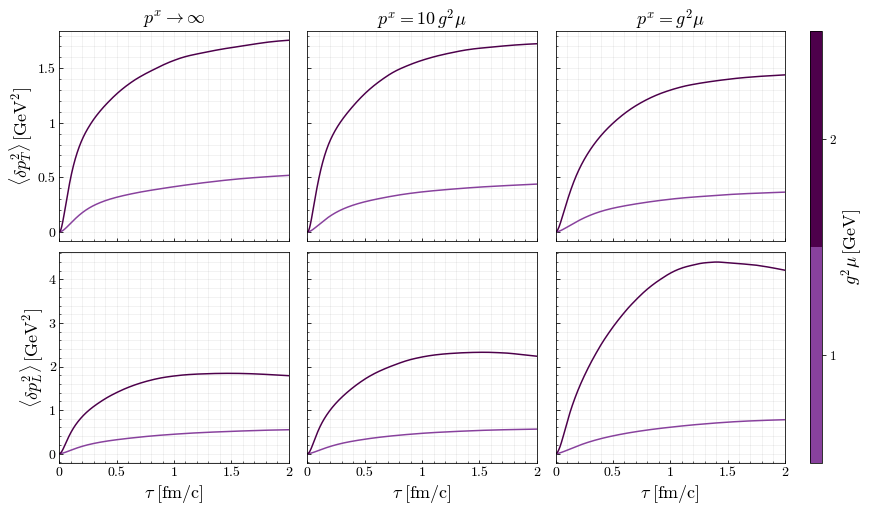

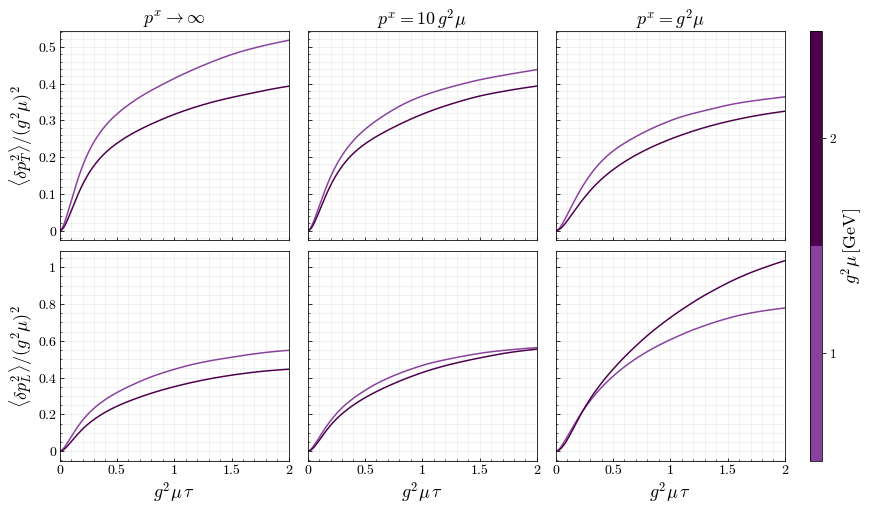

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm, ListedColormap

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

quarks  = results["quarks"]
g2mus   = results["g2mus"]
TAU_MAX = results["TAU_MAX"]
mode    = results["mode"]

# Colormap indexed by g2mu
n    = len(g2mus)
skip = 3
cmap_full = cm.get_cmap('BuPu', n + skip)
colors = [cmap_full(i + skip) for i in range(n)]
cmap_d = ListedColormap(colors)
norm_d = BoundaryNorm(np.arange(0.5, n + 1.5), cmap_d.N)

# Column titles
if mode == 'hq':
    titles = [r'$m\rightarrow\infty$',
              r'$m_b = 4.18\,\mathrm{GeV}$',
              r'$m_c = 1.27\,\mathrm{GeV}$']
elif mode == 'jet':
    titles = [r'$p^x\rightarrow\infty$',
              r'$p^x = 10\,g^2\mu$',
              r'$p^x = g^2\mu$']

ylabels_abs = [r'$\langle\delta p^2_T\rangle\,[\mathrm{GeV}^2]$',
               r'$\langle\delta p^2_L\rangle\,[\mathrm{GeV}^2]$']
ylabels_sc  = [r'$\langle\delta p^2_T\rangle/(g^2\mu)^2$',
               r'$\langle\delta p^2_L\rangle/(g^2\mu)^2$']

ncols = len(quarks)

def _fmt_ax(ax, show_xlabel, show_ylabel, ylabel_str, xlabel_str, xlim, title=None):
    ax.set_xlim(*xlim)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.minorticks_on()
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.tick_params(axis='both', which='minor', direction='in')
    if show_xlabel:
        ax.set_xlabel(xlabel_str, fontsize=18)
    else:
        ax.tick_params(labelbottom=False)
    if show_ylabel:
        ax.set_ylabel(ylabel_str, fontsize=18)
    if title is not None:
        ax.set_title(title, fontsize=18)

def _add_cbar(fig, axes):
    sm = plt.cm.ScalarMappable(cmap=cmap_d, norm=norm_d)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.02, aspect=60)
    cbar.set_label(r'$g^2\mu\,[\mathrm{GeV}]$', fontsize=18)
    cbar.set_ticks(np.arange(1, n + 1))
    cbar.set_ticklabels([str(q) for q in g2mus])
    cbar.ax.tick_params(labelsize=13)
    return cbar

def make_fig(scaled=False):
    fig, axes = plt.subplots(2, ncols, figsize=(4 * ncols, 7),
                             sharey='row', constrained_layout=True)

    for iq, quark in enumerate(quarks):
        for ig, g2mu_val in enumerate(g2mus):
            key  = str(g2mu_val)
            psq_ = np.array(results["psq"][quark][key])
            # Reconstruct tau from psq length to handle any N_eff mismatch in saved data
            tau  = np.linspace(0, TAU_MAX, len(psq_))

            pT = psq_[:, 0] + psq_[:, 1]
            pL = psq_[:, 2]

            if scaled:
                x  = tau * g2mu_val
                yT = pT / g2mu_val**2
                yL = pL / g2mu_val**2
                mask = x <= 2.0
                axes[0, iq].plot(x[mask], yT[mask], color=colors[ig], linewidth=1.5)
                axes[1, iq].plot(x[mask], yL[mask], color=colors[ig], linewidth=1.5)
            else:
                axes[0, iq].plot(tau, pT, color=colors[ig], linewidth=1.5)
                axes[1, iq].plot(tau, pL, color=colors[ig], linewidth=1.5)

    if scaled:
        xlabel_str = r'$g^2\mu\,\tau$'
        xlim       = (0, 2.0)
    else:
        xlabel_str = r'$\tau\;[\mathrm{fm/c}]$'
        xlim       = (0, TAU_MAX)

    ylabels = ylabels_sc if scaled else ylabels_abs

    for iq in range(ncols):
        _fmt_ax(axes[0, iq], show_xlabel=False, show_ylabel=(iq == 0),
                ylabel_str=ylabels[0], xlabel_str=xlabel_str, xlim=xlim, title=titles[iq])
        _fmt_ax(axes[1, iq], show_xlabel=True,  show_ylabel=(iq == 0),
                ylabel_str=ylabels[1], xlabel_str=xlabel_str, xlim=xlim)

    _add_cbar(fig, axes)
    return fig

fig        = make_fig(scaled=False)
fig_scaled = make_fig(scaled=True)
plt.show()

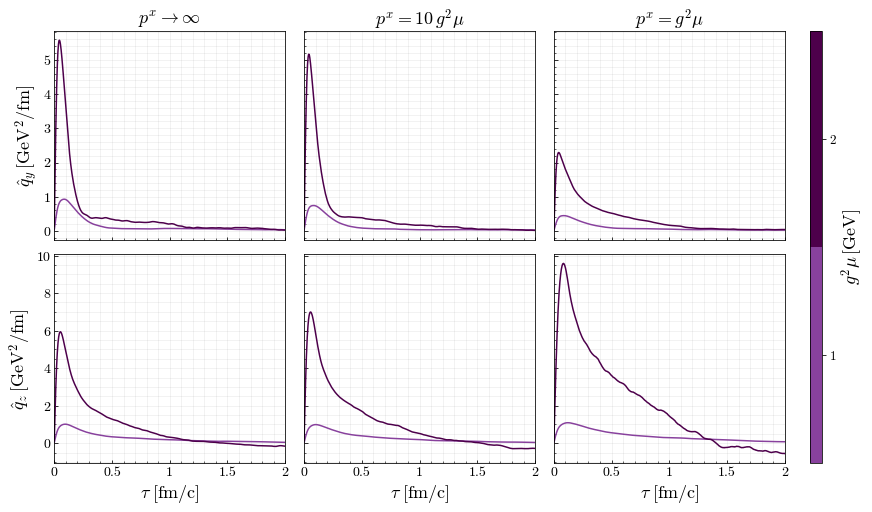

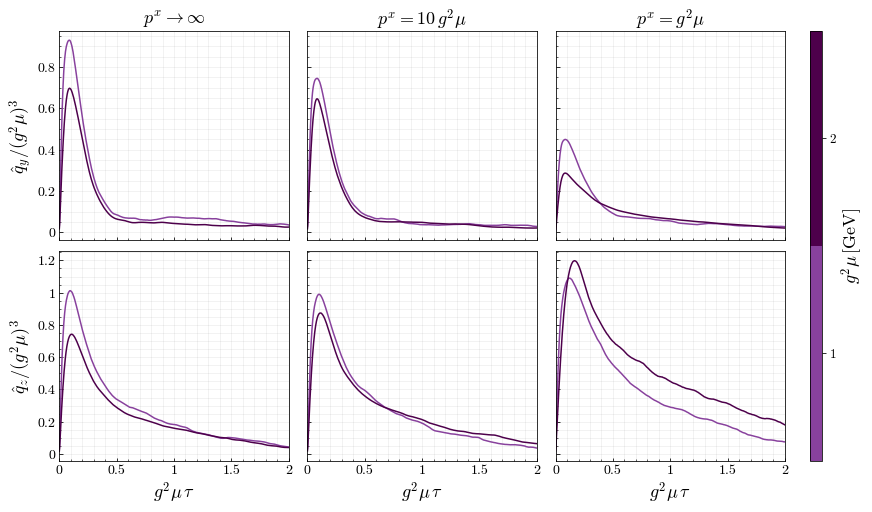

In [ ]:
ylabels_qhat_abs = [r'$\hat{q}_y\,[\mathrm{GeV}^2/\mathrm{fm}]$',
                    r'$\hat{q}_z\,[\mathrm{GeV}^2/\mathrm{fm}]$']
ylabels_qhat_sc  = [r'$\hat{q}_y/(g^2\mu)^3$',
                    r'$\hat{q}_z/(g^2\mu)^3$']

def make_qhat_fig(scaled=False):
    fig, axes = plt.subplots(2, ncols, figsize=(4 * ncols, 7),
                             sharey='row', constrained_layout=True)

    for iq, quark in enumerate(quarks):
        for ig, g2mu_val in enumerate(g2mus):
            key  = str(g2mu_val)
            psq_ = np.array(results["psq"][quark][key])
            # Reconstruct tau from psq length to handle any N_eff mismatch in saved data
            tau  = np.linspace(0, TAU_MAX, len(psq_))

            py = psq_[:, 1]
            pz = psq_[:, 2]

            qhat_y = np.gradient(py, tau)
            qhat_z = np.gradient(pz, tau)

            if scaled:
                x  = tau * g2mu_val
                yy = qhat_y / g2mu_val**3
                yz = qhat_z / g2mu_val**3
                mask = x <= 2.0
                axes[0, iq].plot(x[mask], yy[mask], color=colors[ig], linewidth=1.5)
                axes[1, iq].plot(x[mask], yz[mask], color=colors[ig], linewidth=1.5)
            else:
                axes[0, iq].plot(tau, qhat_y, color=colors[ig], linewidth=1.5)
                axes[1, iq].plot(tau, qhat_z, color=colors[ig], linewidth=1.5)

    if scaled:
        xlabel_str = r'$g^2\mu\,\tau$'
        xlim       = (0, 2.0)
        ylabels    = ylabels_qhat_sc
    else:
        xlabel_str = r'$\tau\;[\mathrm{fm/c}]$'
        xlim       = (0, TAU_MAX)
        ylabels    = ylabels_qhat_abs

    for iq in range(ncols):
        _fmt_ax(axes[0, iq], show_xlabel=False, show_ylabel=(iq == 0),
                ylabel_str=ylabels[0], xlabel_str=xlabel_str, xlim=xlim, title=titles[iq])
        _fmt_ax(axes[1, iq], show_xlabel=True,  show_ylabel=(iq == 0),
                ylabel_str=ylabels[1], xlabel_str=xlabel_str, xlim=xlim)

    _add_cbar(fig, axes)
    return fig

fig_qhat        = make_qhat_fig(scaled=False)
fig_qhat_scaled = make_qhat_fig(scaled=True)
plt.show()

## Read data from files using Julia

In [ ]:
using Pickle

function string_as_varname(s::AbstractString,v::Any)
    s=Symbol(s)
    return @eval (($s) = ($v))
end

file = "results/Qs_mom_broad_wong_beauty.pickle"
data = Pickle.npyload(file)
mom_broad_wong = data["mom_broad"]
tau_wong = data["tau"]

quarks = data["quarks"]
Qss = string.(data["Qs"])

5-element Vector{String}:
 "1"
 "1.5"
 "2"
 "2.5"
 "3"

## Plot the results using Makie from Julia

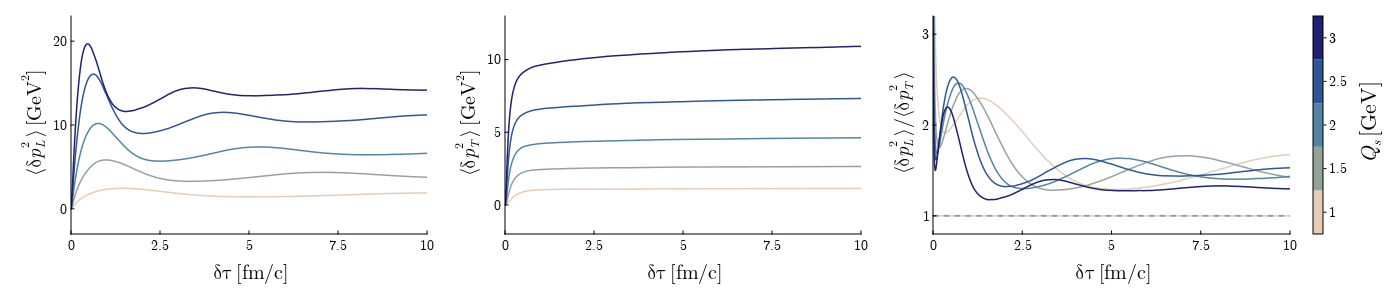

CairoScreen{Cairo.CairoSurfaceBase{UInt32}} with surface:
Cairo.CairoSurfaceBase{UInt32}(Ptr{Nothing} @0x000000000c91dfd0, 7000.0, 1500.0)


In [ ]:
using CairoMakie
using ColorSchemes

segmented_cmap = cgrad(:lapaz, 16, categorical = true)
colors = [segmented_cmap[14], segmented_cmap[11], segmented_cmap[8], segmented_cmap[5], segmented_cmap[2]]
linestyles = [:dash, :dashdot, :dot]

fig = Figure(resolution = (1400, 300), font = "CMU Serif")
ylabels = [L"\langle\delta p_L^2\,\rangle\,\mathrm{[GeV^2]}", L"\langle\delta p_T^2\,\rangle\,\mathrm{[GeV^2]}", 
        L"\langle\delta p^2_L\,\rangle/\langle\delta p^2_T\,\rangle"]
axes = [Axis(fig[1, i], 
        xlabel=L"\delta\tau\,\mathrm{[fm/c]}", ylabel=ylabels[i],
        rightspinevisible = false, topspinevisible = false, xlabelsize = 20, ylabelsize= 20, xticklabelsize=14, yticklabelsize=14,
        xtickalign = 1, xticksize=4, ytickalign=1, yticksize=4, xgridvisible = false, ygridvisible = false) for i in 1:3]

i = 1
iq = 1
tag_low, tag_high = quarks[iq] * "_Qs_" * Qss[1], quarks[iq] * "_Qs_" * Qss[length(Qss)]
δτ_wong = Float64.(tau_wong[tag_low])
mom_broad_L_low, mom_broad_L_high = mom_broad_wong[tag_low][:, 3] , mom_broad_wong[tag_high][:, 3]
# band!(axes[1], δτ_wong, mom_broad_L_low, mom_broad_L_high; color = transpose(reverse(δτ_wong)), colormap = (:lapaz, 0.1))
mom_broad_T_low, mom_broad_T_high = mom_broad_wong[tag_low][:, 1] + mom_broad_wong[tag_low][:, 2], mom_broad_wong[tag_high][:, 1] + mom_broad_wong[tag_high][:, 2]
# band!(axes[2], δτ_wong, mom_broad_T_low, mom_broad_T_high; color = transpose(reverse(δτ_wong)), colormap = (:lapaz, 0.1))
ratio_low, ratio_high = mom_broad_L_low./mom_broad_T_low, mom_broad_L_high./mom_broad_T_high

for iQs in 1:length(Qss)
        tag_wong = quarks[iq] * "_Qs_" * Qss[iQs]
        δτ_wong = Float64.(tau_wong[tag_wong])

        mom_broad_L_wong = mom_broad_wong[tag_wong][:, 3]
        lines!(axes[1], δτ_wong, mom_broad_L_wong, linewidth = 1.5, color=colors[iQs])
        mom_broad_T_wong = mom_broad_wong[tag_wong][:, 1] + mom_broad_wong[tag_wong][:, 2]
        lines!(axes[2], δτ_wong, mom_broad_T_wong, linewidth = 1.5, color=colors[iQs])
        ratio = mom_broad_L_wong./mom_broad_T_wong
        string_as_varname("wong_Qs_"*string(iQs), lines!(axes[3], δτ_wong, ratio, linewidth = 1.5, color=colors[iQs]))
end

for i in 1:3
        xlims!(axes[i], 0, 10)
        axes[i].xticks = ([0, 2.5, 5, 7.5, 10], ["0", "2.5", "5", "7.5", "10"])
end
ylims!(axes[1], -3, 23)
ylims!(axes[2], -2, 13)
ylims!(axes[3], 0.8, 3.2)
axes[1].yticks = ([0, 10, 20], ["0", "10", "20"])
axes[3].yticks = ([1, 2, 3], ["1", "2", "3"])

lines!(axes[3], δτ_wong, ones(length(δτ_wong)), linewidth = 1.8, color=(:grey60, 0.4))
lines!(axes[3], δτ_wong, ones(length(δτ_wong)), linewidth = 1.8, color=:grey60, linestyle=:dash)

cbar = Colorbar(fig[1, 4], limits = (1, 6), colormap =  cgrad(colors, 5, categorical = true), size = 25, labelsize = 22, width = 10, flipaxis = true,
ticksize=3, tickalign = 0, ticklabelsize = 14, height = Relative(1), label=L"Q_s\,\mathrm{[GeV]}")
cbar.ticks = ([1.5, 2.5, 3.5, 4.5, 5.5],  Qss)

display(fig)
save("plots/mom_broad_Qs_beauty.png", fig, px_per_unit = 5.0) 

In [ ]:
# [Gev * fm]
hbarc = 0.197326 

0.197326

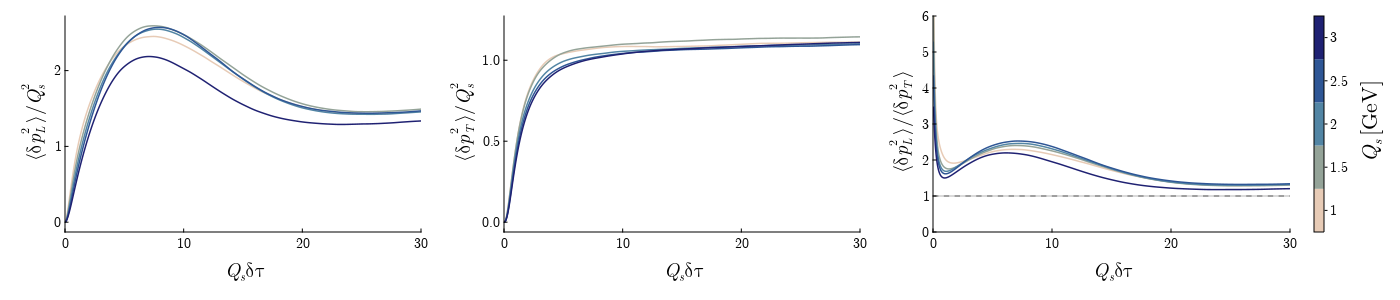

CairoScreen{Cairo.CairoSurfaceBase{UInt32}} with surface:
Cairo.CairoSurfaceBase{UInt32}(Ptr{Nothing} @0x000000000c229710, 7000.0, 1500.0)


In [ ]:
using CairoMakie
using ColorSchemes

segmented_cmap = cgrad(:lapaz, 16, categorical = true)
colors = [segmented_cmap[14], segmented_cmap[11], segmented_cmap[8], segmented_cmap[5], segmented_cmap[2]]
linestyles = [:dash, :dashdot, :dot]

fig = Figure(resolution = (1400, 300), font = "CMU Serif")
ylabels = [L"\langle\delta p_L^2\,\rangle/Q_s^2", L"\langle\delta p_T^2\,\rangle/Q_s^2", 
        L"\langle\delta p^2_L\,\rangle/\langle\delta p^2_T\,\rangle"]
axes = [Axis(fig[1, i], 
        xlabel=L"Q_s\delta\tau", ylabel=ylabels[i],
        rightspinevisible = false, topspinevisible = false, xlabelsize = 20, ylabelsize= 20, xticklabelsize=14, yticklabelsize=14,
        xtickalign = 1, xticksize=4, ytickalign=1, yticksize=4, xgridvisible = false, ygridvisible = false) for i in 1:3]

i = 1
iq = 1
δτ_wong = Float64.(tau_wong[tag_low])

for iQs in 1:length(Qss)
        tag_wong = quarks[iq] * "_Qs_" * Qss[iQs]
        Qs_value = parse(Float64, Qss[iQs])
        δτ_wong = Float64.(tau_wong[tag_wong])*Qs_value/hbarc

        mom_broad_L_wong = mom_broad_wong[tag_wong][:, 3]/Qs_value^2
        lines!(axes[1], δτ_wong, mom_broad_L_wong, linewidth = 1.5, color=colors[iQs])
        mom_broad_T_wong = (mom_broad_wong[tag_wong][:, 1] + mom_broad_wong[tag_wong][:, 2])/Qs_value^2
        lines!(axes[2], δτ_wong, mom_broad_T_wong, linewidth = 1.5, color=colors[iQs])
        ratio = mom_broad_L_wong./mom_broad_T_wong
        string_as_varname("wong_Qs_"*string(iQs), lines!(axes[3], δτ_wong, ratio, linewidth = 1.5, color=colors[iQs]))
end

for i in 1:3
        xlims!(axes[i], 0, 30)
        axes[i].xticks = ([0, 10, 20, 30], ["0", "10", "20", "30"])
end
# ylims!(axes[1], 0, 1.6)
# ylims!(axes[2], 0, 0.8)
ylims!(axes[3], 0, 6)
# axes[1].yticks = ([0.5, 1, 1.5], ["0.5", "1", "1.5"])
# axes[2].yticks = ([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"])
# axes[3].yticks = ([1, 3, 5], ["1", "3", "5"])

lines!(axes[3], δτ_wong, ones(length(δτ_wong)), linewidth = 1.8, color=(:grey60, 0.4))
lines!(axes[3], δτ_wong, ones(length(δτ_wong)), linewidth = 1.8, color=:grey60, linestyle=:dash)

cbar = Colorbar(fig[1, 4], limits = (1, 6), colormap =  cgrad(colors, 5, categorical = true), size = 25, labelsize = 22, width = 10, flipaxis = true,
ticksize=3, tickalign = 0, ticklabelsize = 14, height = Relative(1), label=L"Q_s\,\mathrm{[GeV]}")
cbar.ticks = ([1.5, 2.5, 3.5, 4.5, 5.5],  Qss)

display(fig)
save("plots/mom_broad_tauQs_beauty.png", fig, px_per_unit = 5.0) 